<a href="https://colab.research.google.com/github/steven030/vehicle-co2-consumption-analysis/blob/main/Analisis_Exploratorio_para_consumo_vehiculo_Agrupacion_Variables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Continuaremos con el EDA de DataSet de vehiculos ya limpio**

In [205]:
#importamos las librerias necesaria para la importacion del dataset
from google.colab import drive

#importamos librerias graficas
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

#importamos librerias matematicas
from scipy.stats import stats
import numpy as np

#importamos pandas
import pandas as pd



# **Importamos el dataset de nuestra carpeta de Drive**

In [206]:
import os

#montamos nuestro disco en drive
drive.mount('/content/drive')



#!ls /content/drive/MyDrive/Colab\ Notebooks

df_veh = pd.DataFrame()

if os.path.exists('/content/drive/MyDrive/Colab Notebooks/vehiculos_originales-limpio_analisis.csv'):

  print("DataSet Importado con exito!")
  df_veh = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/vehiculos_originales-limpio_analisis.csv')

else:
    print("Error archivo no existe!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataSet Importado con exito!


In [207]:
df_veh.head()

,Fabricante,modelo,year,desplazamiento,cilindros,traccion,transmision,clase,combustible,consumo,co2
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500


In [208]:
def unique_Col_value(df):
  for col in df:
    print(f"{df[col].name} | {len(df[col].unique())} |{ df[col].dtype}")


unique_Col_value(df_veh)

Fabricante | 129 |object
modelo | 3734 |object
year | 35 |int64
desplazamiento | 66 |float64
cilindros | 10 |float64
traccion | 38 |object
transmision | 8 |object
clase | 34 |object
combustible | 13 |object
consumo | 49 |int64
co2 | 596 |float64


# **Agrupacion de variables categoricas**

In [209]:
df_veh.clase.unique()

array(['Special Purpose Vehicle 2WD', 'Midsize Cars', 'Subcompact Cars',
       'Compact Cars', 'Sport Utility Vehicle - 4WD',
       'Small Sport Utility Vehicle 2WD',
       'Small Sport Utility Vehicle 4WD', 'Two Seaters',
       'Sport Utility Vehicle - 2WD', 'Special Purpose Vehicles',
       'Special Purpose Vehicle 4WD', 'Small Station Wagons',
       'Minicompact Cars', 'Midsize-Large Station Wagons',
       'Midsize Station Wagons', 'Large Cars',
       'Standard Sport Utility Vehicle 4WD',
       'Standard Sport Utility Vehicle 2WD', 'Minivan - 4WD',
       'Minivan - 2WD', 'Vans', 'Vans, Cargo Type',
       'Vans, Passenger Type', 'Standard Pickup Trucks 2WD',
       'Standard Pickup Trucks', 'Standard Pickup Trucks/2wd',
       'Small Pickup Trucks 2WD', 'Standard Pickup Trucks 4WD',
       'Small Pickup Trucks 4WD', 'Small Pickup Trucks', 'Vans Passenger',
       'Special Purpose Vehicle', 'Special Purpose Vehicles/2wd',
       'Special Purpose Vehicles/4wd'], dtype=object

In [210]:
pequenos = ['Compact Cars', 'Two Seaters', 'SubCompact Cars']
medianos = ['MidSize Cars']
grandes = ['Large Cars']

df_veh.loc[df_veh['clase'].isin(pequenos),'Clase_Tipo'] = "Coches Pequeños"
df_veh.loc[df_veh['clase'].isin(medianos),'Clase_Tipo'] = "Coches Medianos"
df_veh.loc[df_veh['clase'].isin(grandes),'Clase_Tipo'] = "Coches Grandes"

df_veh.loc[df_veh['clase'].str.contains('Truck'),'Clase_Tipo'] = "Camionestas"
df_veh.loc[df_veh['clase'].str.contains('Special Purpose'),'Clase_Tipo'] = "Vehiculos Especiales"
df_veh.loc[df_veh['clase'].str.contains('Sport Utility'),'Clase_Tipo'] = "Deportivos"
df_veh.loc[df_veh['clase'].str.contains('Station'),'Clase_Tipo'] = "Coche Familiar"
df_veh.loc[df_veh['clase'].str.contains('van'),'Clase_Tipo'] = "Furgoneta"

df_veh.Clase_Tipo = df_veh.Clase_Tipo.astype('category')
df_veh.Clase_Tipo.value_counts()

,count
Clase_Tipo,
Coches Pequeños,7178
Camionestas,5439
Deportivos,5289
Coche Familiar,2533
Vehiculos Especiales,2214
Coches Grandes,1837
Furgoneta,386


In [211]:
df_veh.dtypes
#df_veh = df_veh.dropna()

,0
Fabricante,object
modelo,object
year,int64
desplazamiento,float64
cilindros,float64
traccion,object
transmision,object
clase,object
combustible,object
consumo,int64


In [212]:
trac = df_veh['traccion']
transmision  =df_veh['transmision']
df_veh['traccion'] = df_veh['transmision']
df_veh['transmision'] = trac

In [213]:
df_veh.traccion.unique()

array(['2-Wheel Drive', 'Rear-Wheel Drive', 'Front-Wheel Drive',
       '4-Wheel or All-Wheel Drive', 'All-Wheel Drive', nan,
       '4-Wheel Drive', 'Part-time 4-Wheel Drive'], dtype=object)

In [214]:
pd.set_option('chained_assignment', None)

In [215]:
df_veh['traccion_tipo'] = 'dos'
df_veh['traccion_tipo'][df_veh.traccion.isin(['4-Wheel or All-Wheel Drive',"All-Wheel Drive","4-Wheel Drive","Part-time 4-Wheel Drive"])] = "Cuatro"

/tmp/ipykernel_19027/1192019994.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_veh['traccion_tipo'][df_veh.traccion.isin(['4-Wheel or All-Wheel Drive',"All-Wheel Drive","4-Wheel Drive","Part-time 4-Wheel Drive"])] = "Cuatro"


In [216]:
df_veh.traccion_tipo.value_counts()

,count
traccion_tipo,
dos,26868
Cuatro,9923


In [217]:
df_veh.traccion_tipo = df_veh.traccion_tipo.astype("category")

In [218]:
df_veh.dtypes

,0
Fabricante,object
modelo,object
year,int64
desplazamiento,float64
cilindros,float64
traccion,object
transmision,object
clase,object
combustible,object
consumo,int64


In [219]:
df_veh.transmision.unique()

array(['Automatic 3-spd', 'Automatic 4-spd', 'Manual 5-spd',
       'Automatic (S5)', 'Manual 6-spd', 'Automatic 5-spd',
       'Automatic (AM8)', 'Automatic (AM-S8)', 'Automatic (AV-S7)',
       'Automatic (S6)', 'Automatic (S9)', 'Automatic (AM-S7)',
       'Automatic (S4)', 'Automatic (AM-S9)', 'Automatic (S7)',
       'Automatic (AM7)', 'Automatic (AM6)', 'Automatic 6-spd',
       'Automatic 8-spd', 'Manual 4-spd', 'Automatic (S8)',
       'Manual 7-spd', 'Automatic (AM-S6)', 'Auto(AM-S6)',
       'Automatic (variable gear ratios)', 'Automatic (AV-S8)',
       'Automatic (A1)', 'Automatic (AV-S6)', 'Manual 3-spd',
       'Automatic (S10)', 'Automatic 9-spd', 'Manual 4-spd Doubled', nan,
       'Automatic (L4)', 'Automatic (L3)', 'Automatic (AV-S10)',
       'Automatic 7-spd', 'Automatic (AM5)'], dtype=object)

In [220]:
df_veh['transmision_tipo'] = "Transmision Automatica"
df_veh.loc[df_veh['transmision'].str.contains('Manual', case=False,na=False),'transmision_tipo'] = 'Transmision Manual'

In [221]:
df_veh.shape

(36791, 14)

In [222]:
df_veh.isna().sum()

,0
Fabricante,0
modelo,0
year,0
desplazamiento,2
cilindros,3
traccion,789
transmision,2
clase,0
combustible,0
consumo,0


In [223]:
df_veh['combustible_tipo'] = 'Otros tipos de combustible'
df_veh.loc[df_veh.combustible == 'Regular','combustible_tipo'] = 'Normal'
df_veh.loc[df_veh.combustible == 'Premium','combustible_tipo'] = 'Premium'
df_veh.loc[df_veh.combustible.str.contains('Electricity'),'combustible_tipo'] = 'Hibrido'
df_veh.combustible_tipo = df_veh.combustible_tipo.astype('category')

In [224]:
df_veh.combustible_tipo.unique()

['Normal', 'Premium', 'Otros tipos de combustible', 'Hibrido']
Categories (4, object): ['Hibrido', 'Normal', 'Otros tipos de combustible', 'Premium']

In [225]:
df_veh.combustible_tipo.value_counts()

,count
combustible_tipo,
Normal,24078
Premium,10206
Otros tipos de combustible,2437
Hibrido,70


# **Agrupacion de variables continuas**
una manera sencilla de convertir variables continuas en otras categoricas es mediante el uso de quantiles, en quintiles(5)



In [226]:
tipos_de_motor = ['muy pequeño','Pequeño','Mediano','grande','muy grande']
df_veh['tipos_de_motor'] = pd.qcut(df_veh.desplazamiento,5,tipos_de_motor)



In [227]:
tipos_de_consumo   = ['muy bajo','Bajo','moderado','Alto','muy Alto']
df_veh['tipos_de_consumo'] = pd.qcut(df_veh.consumo,5,tipos_de_consumo)

In [228]:
tipos_de_co2 = ['muy bajo','Bajo','moderado','Alto','muy Alto']
df_veh['tipos_de_co2'] = pd.qcut(df_veh.co2,5,tipos_de_co2)

In [229]:
df_veh.head(5)

,Fabricante,modelo,year,desplazamiento,cilindros,traccion,transmision,clase,combustible,consumo,co2,Clase_Tipo,traccion_tipo,transmision_tipo,combustible_tipo,tipos_de_motor,tipos_de_consumo,tipos_de_co2
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,2-Wheel Drive,Automatic 3-spd,Special Purpose Vehicle 2WD,Regular,17,522.764706,Vehiculos Especiales,dos,Transmision Automatica,Normal,Pequeño,Bajo,Alto
1,AM General,FJ8c Post Office,1984,4.2,6.0,2-Wheel Drive,Automatic 3-spd,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehiculos Especiales,dos,Transmision Automatica,Normal,grande,muy bajo,muy Alto
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Rear-Wheel Drive,Automatic 3-spd,Special Purpose Vehicle 2WD,Regular,16,555.437500,Vehiculos Especiales,dos,Transmision Automatica,Normal,Pequeño,muy bajo,Alto
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Rear-Wheel Drive,Automatic 3-spd,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehiculos Especiales,dos,Transmision Automatica,Normal,grande,muy bajo,muy Alto
4,ASC Incorporated,GNX,1987,3.8,6.0,Rear-Wheel Drive,Automatic 4-spd,Midsize Cars,Premium,16,555.437500,NaN,dos,Transmision Automatica,Premium,grande,muy bajo,Alto


Al ver las primeras lineas del data set podemos observar que tipo_consumo y tipo_co2 estan correlacionadas, es decir que para cada coche que su consumo sea bajo tienen un co2 alto y vise versa.

para ver la relacion haremos un scatterplot



Text(0.5, 1.0, 'Relacion de consumo vs co2')

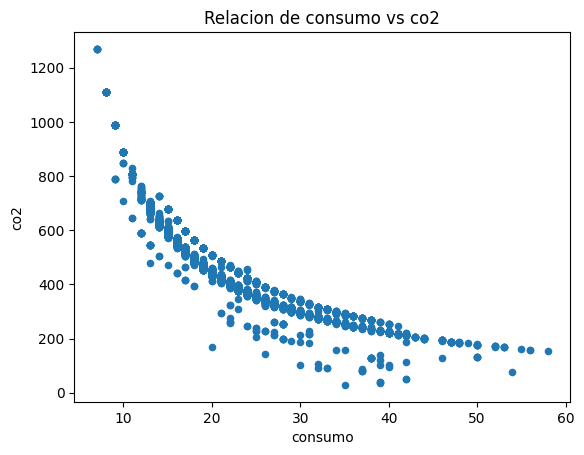

In [230]:
df_veh.plot.scatter(x='consumo',y='co2')
plt.title('Relacion de consumo vs co2')

Podemos ver que en esta grafica que el consumo esta inversamente relacionado, lo que es raro, por lo cual verificamos que en el Dataset el consumo se mide en millas por galon y el CO2 en gramos por mlla. lo que debemos hacer es convertir el consumo de millas por galon  a galones por millas para normalizar y reparar los datos.


In [233]:
litros_por_galon = 3.7854

df_veh['consumo_litros_milla'] = litros_por_galon/df_veh.consumo

df_veh.loc[df_veh['consumo'] > 0, 'galones_por_milla'] = 1 / df_veh['consumo']

In [240]:
from ipywidgets import interact

In [244]:
@interact(col=['consumo_litros_milla','galones_por_milla','consumo'])
def graficarConsumo(col):
  df_veh.plot.scatter(x=col,y='co2')
  plt.title(f'Relacion de {col} vs co2')



interactive(children=(Dropdown(description='col', options=('consumo_litros_milla', 'galones_por_milla', 'consu…

Ahora que hemos corregido las unidades de medida de consumo podemos observar que mientras mas alto es el consumo mas co2 produce, lo que nos indica que hay una correlacion entre estas dos variables


In [249]:
#volveremos a calcular tipo consumo en base a consumo_litros_millas o galones_por_milla
df_veh['tipos_de_consumo'] = pd.qcut(df_veh['consumo_litros_milla'],5,labels=tipos_de_consumo)

In [250]:
df_veh.tipos_de_consumo.value_counts()

,count
tipos_de_consumo,
moderado,10081
muy bajo,7654
Bajo,7488
muy Alto,6780
Alto,4788


In [254]:
df_veh.tipos_de_consumo.head()

,tipos_de_consumo
0,Alto
1,muy Alto
2,Alto
3,muy Alto
4,Alto


In [255]:
df_veh.dtypes

,0
Fabricante,object
modelo,object
year,int64
desplazamiento,float64
cilindros,float64
traccion,object
transmision,object
clase,object
combustible,object
consumo,int64


# **Conclusiones**


* La variable consumo está definida en mpg (millas por galón), por lo que fue necesario convertirla a l/mile (litros por milla) mediante una variable creada (consumo_litros_milla), con el fin de hacerla compatible con la variable CO₂, la cual está expresada en g/mile (gramos por milla).

* Se encontró una correlación positiva entre las variables CO₂ y consumo; es decir, a mayor consumo de combustible por milla, mayor emisión de CO₂. De forma inversa, a menor consumo, menores emisiones de CO₂.




# **Exportar**

Anteriormente se exportaron los datos en formato CSV (Comma-Separated Values). Aunque es un formato ampliamente utilizado, no resulta el más adecuado en entornos de Python y pandas, debido a que no conserva los tipos de datos originales de las columnas. Considerando que el DataFrame contiene variables numéricas y categóricas, se opta por almacenarlo en un formato nativo como pickle, el cual permite preservar tanto la estructura como los tipos de datos.

In [256]:
df_veh.to_pickle('/content/drive/MyDrive/Colab Notebooks/vehiculos_originales-limpio_analisis_variables_Agrupadas.pkl')